In [7]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from src import WeatherModel, Simulation, PvSystem
from src import faults
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

with open("data/settings.json") as f:
    story = json.load(f)
with open("data/modules.json") as f:
    systems = json.load(f)

In [8]:
# Baseline: soiling + degradation already applied by Simulation
wm = WeatherModel.WeatherModel()
sim = Simulation.Simulation(systems, wm, story)
sim.run()

baseline = sim.output["sys1"]
weather  = sim.weather_with_anomalies["sys1"]

In [9]:
# PID fault
sys1 = PvSystem.PvSystem(systems["sys1"])
pid_params = faults.pid(sys1.array.module_parameters, severity=0.5)

out = []
for chunk, params in faults.degradation_timeseries(weather, pid_params):
    sys1.array.module_parameters = params
    out.append(sys1.run_model(chunk).ac)
out_pid = pd.concat(out)

In [10]:
# Open string: 1 of 2 strings disconnected
cfg_open = faults.open_string(systems["sys1"], strings_lost=1)
sys1_open = PvSystem.PvSystem(cfg_open)

out = []
for chunk, params in faults.degradation_timeseries(weather, sys1_open.array.module_parameters):
    sys1_open.array.module_parameters = params
    out.append(sys1_open.run_model(chunk).ac)
out_open = pd.concat(out)

In [11]:
# Inverter fault: 30% AC power loss
out_inverter = faults.inverter_fault(baseline, efficiency_loss=0.3)

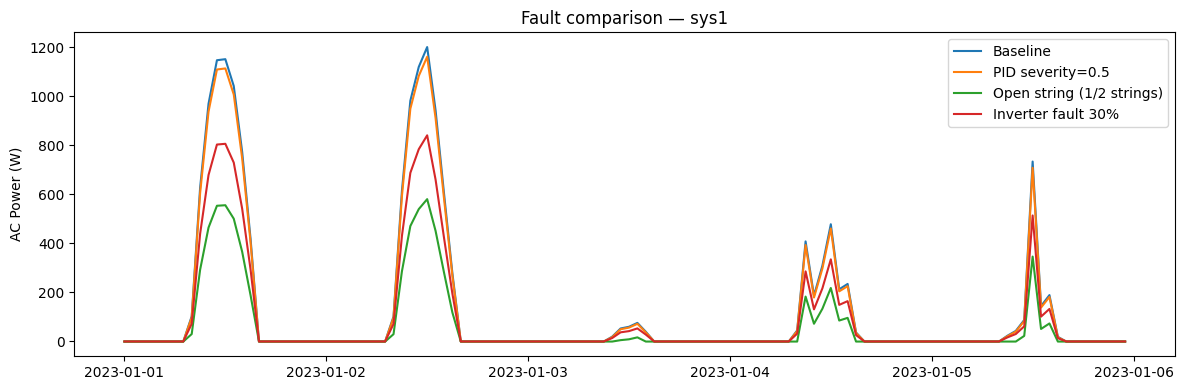

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(baseline,     label="Baseline")
plt.plot(out_pid,      label="PID severity=0.5")
plt.plot(out_open,     label="Open string (1/2 strings)")
plt.plot(out_inverter, label="Inverter fault 30%")
plt.title("Fault comparison — sys1")
plt.ylabel("AC Power (W)")
plt.legend()
plt.tight_layout()
plt.show()